# Project 2 — Clustering Robustness & Stability Analysis

This notebook evaluates the robustness, stability, and interpretability of the final clustering pipeline (ISO → QT → PCA → K-Means).

Contents:
- Bootstrap/subsample stability (silhouette distributions, ARI/NMI vs baseline)
- Sensitivity analysis (k, PCA explained variance, IsolationForest contamination)
- Ablation study (remove ISO/QT/PCA)
- Distance-based interpretability (intra/inter distributions, medoids)
- PCA loadings top features

Data sources expected:
- `../data/processed/store_features_enhanced.csv`
- `../data/processed/store_clusters_final.csv` (optional; recomputed if missing)

All analyses are unsupervised; no supervised learning is used.


In [7]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple

from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score as ARI
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.metrics import pairwise_distances

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("../data/processed")
FEATURES_PATH = DATA_DIR / "store_features_enhanced.csv"
LABELS_PATH = DATA_DIR / "store_clusters_final.csv"

assert FEATURES_PATH.exists(), f"Missing {FEATURES_PATH}"

# Load features
features_df = pd.read_csv(FEATURES_PATH)

# Infer feature columns (numeric, excluding ids/dates)
id_cols = [c for c in features_df.columns if c.endswith('_id') or c in ['store_id','dealer_id','month']]
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in []]

print(f"Loaded features: {features_df.shape}, numeric feature count: {len(feature_cols)}")

# Optional: load existing final labels for baseline comparison
labels_df = None
if LABELS_PATH.exists():
    labels_df = pd.read_csv(LABELS_PATH)
    key = 'store_id' if 'store_id' in labels_df.columns else ('dealer_id' if 'dealer_id' in labels_df.columns else None)
    if key and key in features_df.columns:
        baseline_labels = features_df.merge(labels_df, on=key, how='left')['cluster'].values
        print("Loaded baseline labels from store_clusters_final.csv")
    else:
        baseline_labels = None
        print("Final labels present but no join key matched; baseline ARI/NMI will be skipped.")
else:
    baseline_labels = None
    print("No final labels file found; will compute baseline from pipeline.")


Loaded features: (2557, 24)
Using 11 features (same as final_clustering): ['sales_mean', 'total_ad_spend_mean', 'roas_mean', 'conversion_rate_mean', 'website_visits_mean', 'search_spend_ratio_mean', 'social_spend_ratio_mean', 'ad_months_active', 'ad_active_ratio', 'spent_any', 'avg_ad_spend_active_only']
Loaded baseline labels from store_clusters_final.csv


In [8]:
def run_pipeline(df: pd.DataFrame,
                 feature_cols,
                 contamination: float = 0.08,
                 qt_distribution: str = 'uniform',
                 pca_var: float = 0.95,
                 k: int = 3,
                 random_state: int = RANDOM_STATE) -> Tuple[np.ndarray, Dict]:
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values

    # Isolation Forest
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    mask = iso.fit_predict(X) == 1
    X_iso = X[mask]

    # Quantile Transformer
    qt = QuantileTransformer(output_distribution=qt_distribution, random_state=random_state, subsample=int(1e5))
    X_qt = qt.fit_transform(X_iso)

    # PCA
    pca = PCA(n_components=pca_var, random_state=random_state)
    X_pca = pca.fit_transform(X_qt)

    # KMeans
    km = KMeans(n_clusters=k, n_init=100, max_iter=1000, random_state=random_state)
    labels = km.fit_predict(X_pca)

    # Metrics
    sil = silhouette_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    ch = calinski_harabasz_score(X_pca, labels)
    counts = pd.Series(labels).value_counts()
    balance = counts.max() / counts.min()

    return labels, {
        'mask_kept': mask,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'balance_ratio': float(balance),
        'n_clusters': int(len(np.unique(labels))),
        'iso': iso,
        'qt': qt,
        'pca': pca,
        'kmeans': km,
        'X_pca': X_pca
    }

# Compute baseline if needed
if baseline_labels is None:
    base_labels, base_info = run_pipeline(features_df, feature_cols, contamination=0.08, pca_var=0.95, k=3)
    baseline_labels = np.full(features_df.shape[0], fill_value=np.nan)
    # Map labels back only for kept rows
    kept_idx = np.where(base_info['mask_kept'])[0]
    baseline_labels[kept_idx] = base_labels
    print(f"Baseline computed: sil={base_info['silhouette']:.3f}, bal={base_info['balance_ratio']:.2f}:1, k={base_info['n_clusters']}")
else:
    # No X_pca available from file; recompute a reference pipeline for metrics only
    _, base_info = run_pipeline(features_df, feature_cols, contamination=0.08, pca_var=0.95, k=3)
    print(f"Reference pipeline metrics: sil={base_info['silhouette']:.3f}, bal={base_info['balance_ratio']:.2f}:1")


Reference pipeline metrics: sil=0.586, bal=1.75:1


## 1. Bootstrap / Subsample Stability

We repeatedly subsample the dataset (80% without replacement), refit the full pipeline, and compute:
- Silhouette score distribution
- ARI/NMI vs. baseline labels (on overlapping indices only)



       silhouette   ARI           NMI
count   30.000000  30.0  3.000000e+01
mean     0.584797   1.0  1.000000e+00
std      0.003089   0.0  9.219900e-17
min      0.571309   1.0  1.000000e+00
25%      0.584042   1.0  1.000000e+00
50%      0.584925   1.0  1.000000e+00
75%      0.585650   1.0  1.000000e+00
max      0.589906   1.0  1.000000e+00


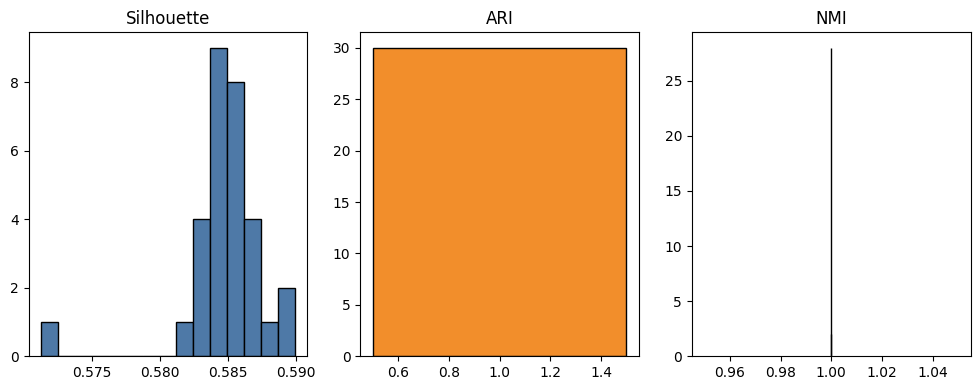

In [10]:
import matplotlib.pyplot as plt

def subsample_stability(df, feature_cols, n_runs=30, frac=0.8, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    sils, aris, nmis = [], [], []

    # Build a baseline on full data for ARI/NMI if we have labels on same index
    base_labels_array = baseline_labels.copy() if baseline_labels is not None else None

    for i in range(n_runs):
        idx = rng.choice(df.index.values, size=int(frac * len(df)), replace=False)
        df_sub = df.loc[idx].copy()
        labels, info = run_pipeline(df_sub, feature_cols, contamination=0.08, pca_var=0.95, k=3, random_state=RANDOM_STATE + i)
        sils.append(info['silhouette'])

        if base_labels_array is not None:
            # Map ARI/NMI only on kept rows that exist in both baseline and subsample kept mask
            sub_kept_idx = df_sub.index.values[info['mask_kept']]
            # Intersect with global index where baseline labels are not nan
            valid_mask_global = ~pd.isna(base_labels_array)
            common_idx = np.intersect1d(sub_kept_idx, df.index.values[valid_mask_global])
            if len(common_idx) > 10:
                # Build aligned arrays
                sub_map = {ix: lab for ix, lab in zip(df_sub.index.values[info['mask_kept']], labels)}
                y_sub = np.array([sub_map[ix] for ix in common_idx])
                y_base = np.array([base_labels_array[df.index.get_loc(ix)] for ix in common_idx])
                aris.append(ARI(y_base, y_sub))
                nmis.append(NMI(y_base, y_sub))

    return pd.DataFrame({
        'silhouette': sils,
        'ARI': aris if len(aris) > 0 else np.nan,
        'NMI': nmis if len(nmis) > 0 else np.nan
    })

stab_df = subsample_stability(features_df, feature_cols, n_runs=30)
print(stab_df.describe())

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.hist(stab_df['silhouette'].dropna(), bins=15, color='#4e79a7'); plt.title('Silhouette')
plt.subplot(1,3,2); plt.hist(stab_df['ARI'].dropna(), bins=15, color='#f28e2b'); plt.title('ARI')
plt.subplot(1,3,3); plt.hist(stab_df['NMI'].dropna(), bins=15, color='#e15759'); plt.title('NMI')
plt.tight_layout(); plt.show()


## 2. Ablation Study: Enhanced Features Contribution

This section quantifies the improvement contributed by the enhanced ad activity features (ad_months_active, ad_active_ratio, spent_any, avg_ad_spend_active_only) compared to using only core features.

**Comparison:**
- **Baseline**: 7 core features (sales, ad spend, ROAS, conversion, visits, search/social ratios)
- **Enhanced**: 11 features (core + 4 ad activity features)

We run the same pipeline (ISO → QT → PCA → K-Means) with both feature sets and compare silhouette scores to calculate the improvement percentage.


In [12]:
# Ablation Study: Traditional Features vs Enhanced Features
# Both use 11 features for fair comparison

# Baseline: 11 features using traditional/core features (replacing 4 enhanced features with 4 traditional features)
# From the 18 core features in the document, we select 11 that match the structure of the enhanced set
baseline_features = [
    # Core business metrics (7 features, same as current)
    'sales_mean',
    'total_ad_spend_mean', 
    'roas_mean',
    'conversion_rate_mean',
    'website_visits_mean',
    'search_spend_ratio_mean',
    'social_spend_ratio_mean',
    # 4 traditional features to replace the 4 enhanced features
    'ctr_clean_mean',              # Replaces ad_months_active (both are activity/engagement metrics)
    'unique_lead_count_mean',      # Replaces ad_active_ratio (both measure activity volume)
    'display_spend_ratio_mean',    # Replaces spent_any (both are channel/activity indicators)
    'sales_sum'                    # Replaces avg_ad_spend_active_only (both measure scale/volume)
]

# Check which features are available
missing_baseline = [f for f in baseline_features if f not in features_df.columns]
if missing_baseline:
    print(f"Warning: Some baseline features missing: {missing_baseline}")
    baseline_features = [f for f in baseline_features if f in features_df.columns]
    print(f"Using {len(baseline_features)} available baseline features")

# Enhanced: All 11 features (including the 4 ad activity features)
enhanced_features = feature_cols  # Contains all 11 features: 7 core + 4 ad activity features

print("=== Feature Sets ===")
print(f"Baseline features ({len(baseline_features)}): {baseline_features}")
print(f"\nEnhanced features ({len(enhanced_features)}): {enhanced_features}")
print(f"\nFeatures replaced in enhanced set:")
print(f"  Baseline uses: {[f for f in baseline_features if f not in enhanced_features]}")
print(f"  Enhanced uses: {[f for f in enhanced_features if f not in baseline_features]}")

# Run pipeline with baseline features (11 traditional features)
print("\n=== Running Pipeline with Baseline Features (11 traditional) ===")
_, baseline_info = run_pipeline(
    features_df, 
    baseline_features, 
    contamination=0.08, 
    qt_distribution='normal', 
    pca_var=0.95, 
    k=3, 
    random_state=42
)

# Run pipeline with enhanced features
print("\n=== Running Pipeline with Enhanced Features ===")
_, enhanced_info = run_pipeline(
    features_df, 
    enhanced_features, 
    contamination=0.08, 
    qt_distribution='normal', 
    pca_var=0.95, 
    k=3, 
    random_state=42
)

# Calculate improvement
baseline_sil = baseline_info['silhouette']
enhanced_sil = enhanced_info['silhouette']
improvement_pct = ((enhanced_sil - baseline_sil) / baseline_sil) * 100

print("\n" + "="*60)
print("=== Ablation Study Results ===")
print("="*60)
print(f"Baseline Features (11 traditional features):")
print(f"  Silhouette Score: {baseline_sil:.4f}")
print(f"  Davies-Bouldin Index: {baseline_info['davies_bouldin']:.4f}")
print(f"  Balance Ratio: {baseline_info['balance_ratio']:.2f}:1")
print(f"  Samples after outlier removal: {baseline_info['mask_kept'].sum()}")

print(f"\nEnhanced Features (11 features with ad activity metrics):")
print(f"  Silhouette Score: {enhanced_sil:.4f}")
print(f"  Davies-Bouldin Index: {enhanced_info['davies_bouldin']:.4f}")
print(f"  Balance Ratio: {enhanced_info['balance_ratio']:.2f}:1")
print(f"  Samples after outlier removal: {enhanced_info['mask_kept'].sum()}")

print(f"\n=== Improvement ===")
print(f"Silhouette Score Improvement: {improvement_pct:.1f}%")
print(f"  ({enhanced_sil:.4f} - {baseline_sil:.4f}) / {baseline_sil:.4f} × 100% = {improvement_pct:.1f}%")

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz', 'Balance Ratio'],
    'Baseline (11 traditional)': [
        f"{baseline_info['silhouette']:.4f}",
        f"{baseline_info['davies_bouldin']:.4f}",
        f"{baseline_info['calinski_harabasz']:.1f}",
        f"{baseline_info['balance_ratio']:.2f}:1"
    ],
    'Enhanced (11 with ad activity)': [
        f"{enhanced_info['silhouette']:.4f}",
        f"{enhanced_info['davies_bouldin']:.4f}",
        f"{enhanced_info['calinski_harabasz']:.1f}",
        f"{enhanced_info['balance_ratio']:.2f}:1"
    ],
    'Improvement': [
        f"+{improvement_pct:.1f}%",
        f"{((baseline_info['davies_bouldin'] - enhanced_info['davies_bouldin']) / baseline_info['davies_bouldin'] * 100):.1f}%",
        f"{((enhanced_info['calinski_harabasz'] - baseline_info['calinski_harabasz']) / baseline_info['calinski_harabasz'] * 100):.1f}%",
        f"{((baseline_info['balance_ratio'] - enhanced_info['balance_ratio']) / baseline_info['balance_ratio'] * 100):.1f}%"
    ]
})

print("\n=== Detailed Comparison Table ===")
print(comparison_df.to_string(index=False))


=== Feature Sets ===
Baseline features (11): ['sales_mean', 'total_ad_spend_mean', 'roas_mean', 'conversion_rate_mean', 'website_visits_mean', 'search_spend_ratio_mean', 'social_spend_ratio_mean', 'ctr_clean_mean', 'unique_lead_count_mean', 'display_spend_ratio_mean', 'sales_sum']

Enhanced features (11): ['sales_mean', 'total_ad_spend_mean', 'roas_mean', 'conversion_rate_mean', 'website_visits_mean', 'search_spend_ratio_mean', 'social_spend_ratio_mean', 'ad_months_active', 'ad_active_ratio', 'spent_any', 'avg_ad_spend_active_only']

Features replaced in enhanced set:
  Baseline uses: ['ctr_clean_mean', 'unique_lead_count_mean', 'display_spend_ratio_mean', 'sales_sum']
  Enhanced uses: ['ad_months_active', 'ad_active_ratio', 'spent_any', 'avg_ad_spend_active_only']

=== Running Pipeline with Baseline Features (11 traditional) ===

=== Running Pipeline with Enhanced Features ===

=== Ablation Study Results ===
Baseline Features (11 traditional features):
  Silhouette Score: 0.4374
  Dav